In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import heapq

# Time Dependency

In [2]:
network_td = {
    ('s', 'A'): {'morning': 12, 'offpeak': 8, 'evening': 11, 'night': 8}, # night same as offpeak
    ('s', 'B'): {'morning': 14, 'offpeak': 9, 'evening': 12, 'night': 9},
    ('s', 'C'): {'morning': 18, 'offpeak': 12, 'evening': 16, 'night': 12},
    ('A', 'D'): {'morning': 11, 'offpeak': 7, 'evening': 9, 'night': 7},
    ('A', 'E'): {'morning': 12, 'offpeak': 8, 'evening': 11, 'night': 8},
    ('B', 'D'): {'morning': 12, 'offpeak': 8, 'evening': 11, 'night': 8},
    ('B', 'F'): {'morning': 15, 'offpeak': 10, 'evening': 14, 'night': 10},
    ('C', 'F'): {'morning': 9, 'offpeak': 6, 'evening': 8, 'night': 6},
    ('C', 'G'): {'morning': 14, 'offpeak': 9, 'evening': 12, 'night': 9},
    ('D', 'H'): {'morning': 11, 'offpeak': 7, 'evening': 9, 'night': 7},
    ('D', 'I'): {'morning': 16, 'offpeak': 11, 'evening': 15, 'night': 11},
    ('E', 'H'): {'morning': 8, 'offpeak': 5, 'evening': 7, 'night': 5},
    ('E', 'I'): {'morning': 12, 'offpeak': 8, 'evening': 11, 'night': 8},
    ('F', 'G'): {'morning': 6, 'offpeak': 4, 'evening': 5, 'night': 4},
    ('F', 'J'): {'morning': 11, 'offpeak': 7, 'evening': 9, 'night': 7},
    ('G', 'J'): {'morning': 15, 'offpeak': 10, 'evening': 14, 'night': 10},
    ('G', 'K'): {'morning': 8, 'offpeak': 5, 'evening': 7, 'night': 5},
    ('H', 'L'): {'morning': 12, 'offpeak': 8, 'evening': 11, 'night': 8},
    ('H', 'M'): {'morning': 9, 'offpeak': 6, 'evening': 8, 'night': 6},
    ('I', 'L'): {'morning': 9, 'offpeak': 6, 'evening': 8, 'night': 6},
    ('I', 'M'): {'morning': 14, 'offpeak': 9, 'evening': 12, 'night': 9},
    ('J', 'K'): {'morning': 11, 'offpeak': 7, 'evening': 9, 'night': 7},
    ('J', 'N'): {'morning': 16, 'offpeak': 11, 'evening': 15, 'night': 11},
    ('K', 'N'): {'morning': 8, 'offpeak': 5, 'evening': 7, 'night': 5},
    ('K', 't'): {'morning': 12, 'offpeak': 8, 'evening': 11, 'night': 8},
    ('L', 'N'): {'morning': 11, 'offpeak': 7, 'evening': 9, 'night': 7},
    ('L', 't'): {'morning': 15, 'offpeak': 10, 'evening': 14, 'night': 10},
    ('M', 'N'): {'morning': 8, 'offpeak': 5, 'evening': 7, 'night': 5},
    ('M', 't'): {'morning': 14, 'offpeak': 9, 'evening': 12, 'night': 9},
    ('N', 't'): {'morning': 6, 'offpeak': 4, 'evening': 5, 'night': 4}
}

def get_travel_time(link, t):
    if 6*60 <= t < 10*60:
        period = 'morning'
    elif 10*60 <= t < 16*60:
        period = 'offpeak'
    elif 16*60 <= t < 20*60:
        period = 'evening'
    else:
        period = 'night'
    return network_td[link][period]

In [3]:
def dijkstra_td(network_td, start, end, departure_time):
    # priority queue: (cost, node)
    queue = [(0, start, departure_time)]
    visited = {}
    predecessors = {}

    while queue:
        cost, node, t = heapq.heappop(queue)

        if node in visited:
            continue
        visited[node] = cost

        if node == end:
            break

        for (u, v) in network_td:
            if u == node:
                travel_time = get_travel_time((u, v), t)
                #edge_cost = costs[0] if weight == 'time' else costs[1]
                #new_cost = cost + edge_cost
                new_cost = cost + travel_time
                arrival_time = t + travel_time

                # TODO: if v not visited, push (new_cost, v) to queue
                if v not in visited:
                    heapq.heappush(queue, (new_cost, v, arrival_time))
                    # TODO: update predecessors[v] = node
                    if v not in predecessors or new_cost < predecessors[v][1]:
                        predecessors[v] = (node, new_cost)

    # TODO: reconstruct path by walking back through predecessors from end to start
    path = []
    current = end
    while current != start:
        path.append(current)
        current = predecessors[current][0]
    path.append(start)
    path.reverse()

    return path, visited[end]

for t in [8*60, 12*60, 17*60]:
    path, cost = dijkstra_td(network_td, 's', 't', departure_time=t)
    print(f"Departure t={t}: {' -> '.join(path)}, cost={cost}")

Departure t=480: s -> C -> G -> K -> t, cost=52
Departure t=720: s -> C -> G -> K -> t, cost=34
Departure t=1020: s -> C -> G -> K -> t, cost=46


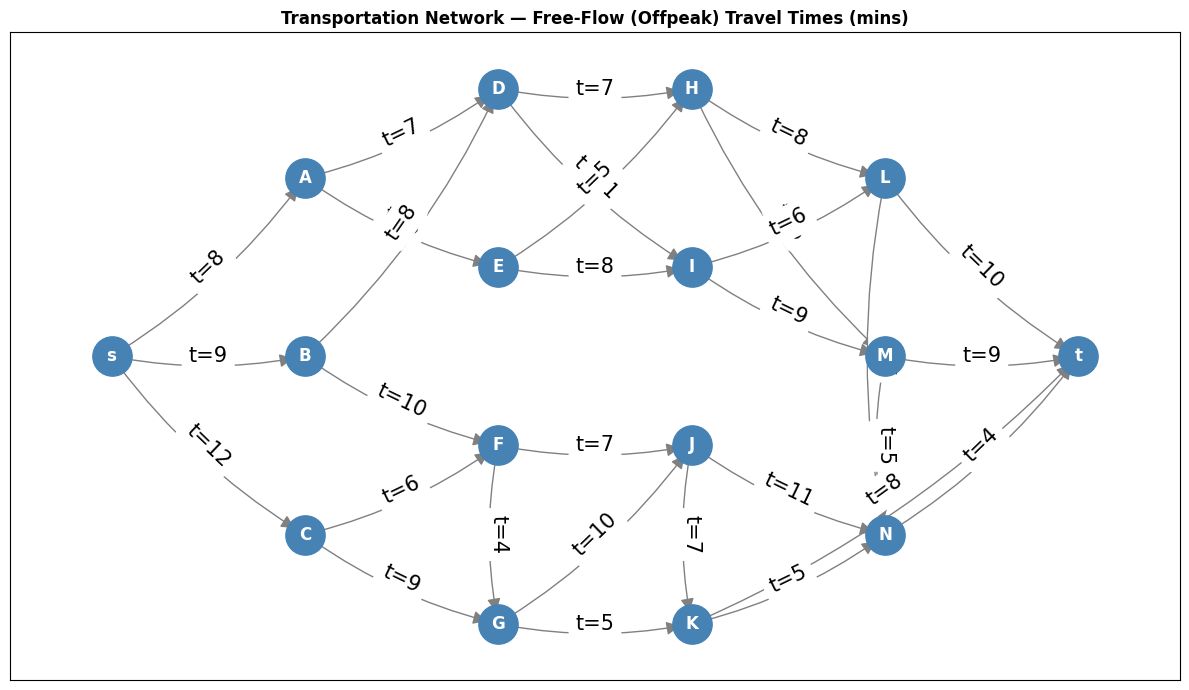

In [4]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()
for (u, v), times in network_td.items():
    G.add_edge(u, v, offpeak=times['offpeak'])

# layered positions — nodes grouped by distance from s
layers = {
    's': 0,
    'A': 1, 'B': 1, 'C': 1,
    'D': 2, 'E': 2, 'F': 2, 'G': 2,
    'H': 3, 'I': 3, 'J': 3, 'K': 3,
    'L': 4, 'M': 4, 'N': 4,
    't': 5
}

# vertical spacing within each layer
layer_nodes = {}
for node, layer in layers.items():
    layer_nodes.setdefault(layer, []).append(node)

pos = {}
for layer, nodes in layer_nodes.items():
    n = len(nodes)
    for i, node in enumerate(sorted(nodes)):
        pos[node] = (layer * 3, -(i - (n-1)/2) * 2)

# draw
fig, ax = plt.subplots(figsize=(12, 7))

nx.draw_networkx_nodes(G, pos, node_color='steelblue', node_size=800, ax=ax)
nx.draw_networkx_labels(G, pos, font_color='white', font_weight='bold', ax=ax)
nx.draw_networkx_edges(G, pos, arrows=True, arrowsize=20, 
                        edge_color='gray', connectionstyle='arc3,rad=0.1', ax=ax)

edge_labels = {
    (u, v): f"t={d['offpeak']}"
    for u, v, d in G.edges(data=True)
}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=15, ax=ax)

ax.set_title("Transportation Network — Free-Flow (Offpeak) Travel Times (mins)", fontweight='bold')
plt.tight_layout()
plt.show()

# Induction

In [5]:
## Forward induction (Dijkstra)

T_min = 6*60
T_max = 21*60
policy = {}

for node in G.nodes():
    for t in range(T_min, T_max + 1):
        if node == 't':
            continue
        path, cost = dijkstra_td(network_td, node, 't', departure_time=t)
        #print(f"From {node} at t={t}: {' -> '.join(path)}, cost={cost}")
        policy[(node, t)] = path[1] # optimal next decision from (n,t)

In [6]:
# Backwards induction (DP, Bellman Eqs)

V = {(n,t): float('inf') for n in G.nodes() for t in range(T_min, T_max + 1)}
policy2 = {}

for t in range(T_min, T_max + 1):
    V[('t', t)] = 0 # boundary conditions


for t in range(T_max - 1, T_min - 1, -1):
    for node in reversed(list(nx.topological_sort(G))):
        if node == 't': # skip terminal node
            continue
        best_cost = float('inf')
        best_next = None
        for (u, v) in G.edges():
            if u == node:
                travel_time = get_travel_time((u,v), t)
                if t + travel_time > T_max:
                    continue
                arrival_time = t + travel_time
                cost = travel_time + V[(v, arrival_time)]
                if cost < best_cost:
                    best_cost = cost
                    best_next = v
        V[(node, t)] = best_cost
        if best_next is not None:
            policy2[(node, t)] = best_next

In [10]:
# Compare against Dijkstra's policy

mismatches = []
for (node, t), next_node in policy.items():
    if (node, t) in policy2:
        if policy2[(node, t)] != next_node:
            mismatches.append((node, t, next_node, policy2[(node, t)]))

#if mismatches:
#    for node, t, p1, p2 in mismatches:
#        print(f"({node}, t={t}): Dijkstra={p1}, DP={p2}")
#else:
#    print("Policies match!")

In [11]:
def extract_path(policy, start, t, max_steps=20):
    path = [start]
    node = start
    for _ in range(max_steps):
        if node == 't' or (node, t) not in policy:
            break
        next_node = policy[(node, t)]
        travel_time = get_travel_time((node, next_node), t)
        t = t + travel_time
        path.append(next_node)
        node = next_node
    return path

The methods may still differ because they are solving slightly different problems. Dijkstra's is moving forward, while DP is moving backwards. Since Dijkstra's is moving forward, it is greedy and short-sided. Thus the DP cases below are always better when the two methods differ.

In [12]:
for node, t, p1, p2 in mismatches:
    path_dijkstra = extract_path(policy, node, t)
    path_dp = extract_path(policy2, node, t)
    _, cost_d = dijkstra_td(network_td, node, 't', t)
    if cost_d != V[(node, t)]:
        print(f"\n({node}, t={t}):")
        print(f"  Dijkstra: {' -> '.join(path_dijkstra)}, cost={cost_d}")
        print(f"  DP:       {' -> '.join(path_dp)}, cost={V[(node, t)]}")


(s, t=557):
  Dijkstra: s -> C -> G -> K -> t, cost=52
  DP:       s -> B -> F -> G -> K -> t, cost=51

(s, t=558):
  Dijkstra: s -> C -> G -> K -> t, cost=52
  DP:       s -> B -> F -> G -> K -> t, cost=51

(s, t=559):
  Dijkstra: s -> A -> E -> H -> M -> t, cost=50
  DP:       s -> C -> F -> G -> K -> t, cost=49

(A, t=569):
  Dijkstra: A -> E -> H -> M -> N -> t, cost=41
  DP:       A -> D -> H -> M -> N -> t, cost=40

(A, t=570):
  Dijkstra: A -> E -> H -> M -> N -> t, cost=41
  DP:       A -> D -> H -> M -> N -> t, cost=40

(A, t=578):
  Dijkstra: A -> E -> H -> M -> t, cost=38
  DP:       A -> D -> H -> M -> N -> t, cost=37

(A, t=579):
  Dijkstra: A -> E -> H -> M -> t, cost=38
  DP:       A -> D -> H -> M -> N -> t, cost=37

(C, t=577):
  Dijkstra: C -> G -> K -> t, cost=34
  DP:       C -> F -> G -> K -> t, cost=31

(C, t=585):
  Dijkstra: C -> G -> K -> t, cost=30
  DP:       C -> F -> G -> K -> t, cost=28

(C, t=1180):
  Dijkstra: C -> G -> K -> t, cost=30
  DP:       C -> 

# Stochastic Travel Times

In [13]:
# (base_mean, base_std) representing free-flow travel time
# higher mean = longer link, higher std = more variable
# travel times now in minutes (5-15 min per link)
network_params = {
    ('s', 'A'): (8, 2),
    ('s', 'B'): (9, 1),
    ('s', 'C'): (12, 3),
    ('A', 'D'): (7, 2),
    ('A', 'E'): (8, 2),
    ('B', 'D'): (8, 1),
    ('B', 'F'): (10, 4),
    ('C', 'F'): (6, 1),
    ('C', 'G'): (9, 2),
    ('D', 'H'): (7, 3),
    ('D', 'I'): (11, 3),
    ('E', 'H'): (5, 1),
    ('E', 'I'): (8, 2),
    ('F', 'G'): (4, 3),
    ('F', 'J'): (7, 2),
    ('G', 'J'): (10, 3),
    ('G', 'K'): (5, 3),
    ('H', 'L'): (8, 2),
    ('H', 'M'): (6, 2),
    ('I', 'L'): (6, 1),
    ('I', 'M'): (9, 2),
    ('J', 'K'): (7, 2),
    ('J', 'N'): (11, 3),
    ('K', 'N'): (5, 1),
    ('K', 't'): (8, 5),
    ('L', 'N'): (7, 2),
    ('L', 't'): (10, 3),
    ('M', 'N'): (5, 1),
    ('M', 't'): (9, 2),
    ('N', 't'): (4, 1),
}

## Example to show risk avoidance

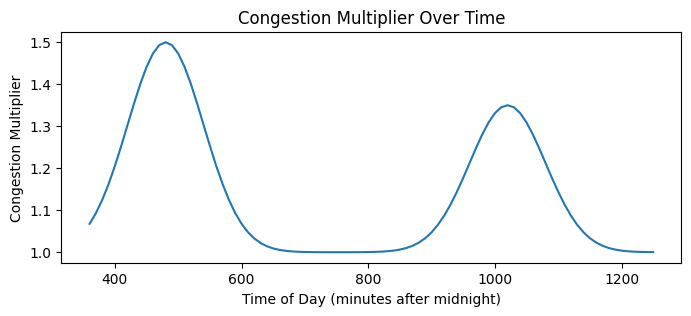

In [14]:
def get_mean(base_mean, t):
    # peaks at t=480 (8am) and t=1020 (5pm) in minutes
    congestion = 1 + 0.5 * (np.exp(-0.5*((t-480)/60)**2) + 0.7*np.exp(-0.5*((t-1020)/60)**2)) # congestion function that gives multiplier given time of day. 
                                                                                              # NOT random and gives same multiplier for all links at a given time. But random sample is taken below with multiplied values
    return base_mean * congestion

plt.figure(figsize=(8, 3))
T_min, T_max = 6*60, 21*60
times = np.arange(T_min, T_max, 10)
congestion = 1 + 0.5 * (np.exp(-0.5*((times-480)/60)**2) + 0.7*np.exp(-0.5*((times-1020)/60)**2))
plt.xlabel("Time of Day (minutes after midnight)")
plt.ylabel("Congestion Multiplier")
plt.title("Congestion Multiplier Over Time")
plt.plot(times, congestion)

def get_std(base_std, t):
    congestion = 1 + 0.3 * (np.exp(-0.5*((t-480)/60)**2) + 0.7*np.exp(-0.5*((t-1020)/60)**2))
    return base_std * congestion

def lognormal_params(mean, std):
    # convert mean and std to lognormal mu and sigma
    sigma2 = np.log(1 + (std/mean)**2)
    mu = np.log(mean) - sigma2/2
    return mu, np.sqrt(sigma2)

def get_stochastic_travel_time(link, t):
    base_mean, base_std = network_params[link]
    mean = get_mean(base_mean, t)
    std = get_std(base_std, t)
    mu, sigma = lognormal_params(mean, std)
    #return max(1, round(np.random.normal(mean, std))) # ensure travel time is at least 1, and round to nearest minute. This is the only stochastic piece!
    return max(base_mean, round(np.random.lognormal(mu, sigma))) # ensure travel time is at least base mean, and round to nearest minute. More realistic this way.

lam = 0
def new_expected_cost(link, t, V, v, lam=0): # change lambda here AND ABOVE.
    # Monte Carlo estimate of expected cost by sampling travel times
    samples = [get_stochastic_travel_time(link, t) for _ in range(100)]
    total_costs = []
    for s in samples:
        arrival = t + s
        if (v, arrival) in V and V[(v, arrival)] != float('inf'): # v is next node
            total_costs.append(s + V[(v, arrival)])
    if not total_costs:
        return float('inf')
    return np.mean(total_costs) + lam * np.std(total_costs)

In [15]:
T_min = 6*60
T_max = 21*60

V_s = {(n, t): float('inf') for n in G.nodes() for t in range(T_min, T_max + 1)}
policy_s = {}

for t in range(T_min, T_max + 1):
    V_s[('t', t)] = 0

for t in range(T_max - 1, T_min - 1, -1):
    for node in reversed(list(nx.topological_sort(G))):
        if node == 't':
            continue
        best_cost = float('inf')
        best_next = None
        for (u, v) in G.edges():
            if u == node:
                cost = new_expected_cost((u, v), t, V_s, v)
                if cost < best_cost:
                    best_cost = cost
                    best_next = v
        V_s[(node, t)] = best_cost
        if best_next is not None:
            policy_s[(node, t)] = best_next

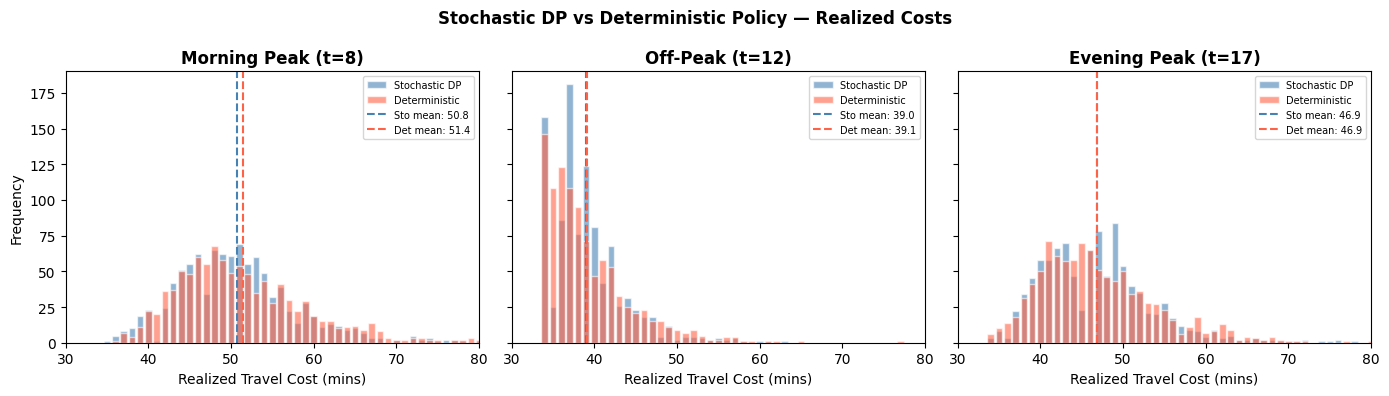

Departure                   Sto Mean   Det Mean    Sto Std    Det Std Sto Utility Det Utility
-----------------------------------------------------------------
Morning Peak (t=8)             50.77      51.42       7.34       8.08     50.77     51.42
Off-Peak (t=12)                39.02      39.11       4.37       5.10     39.02     39.11
Evening Peak (t=17)            46.89      46.86       6.96       7.02     46.89     46.86


In [16]:
def simulate_trip(policy, start, t, T_max=21*60):
    path = [start]
    node = start
    time = t
    total_cost = 0

    while node != 't':
        next_node = policy.get((node, time), None)
        path.append(next_node)
        travel_time = get_stochastic_travel_time((node, next_node), time)
        total_cost += travel_time
        time += travel_time
        if time > T_max:
            return path, float('inf') # if we exceed max time, treat as infinite cost
        node = next_node

    return path, total_cost


departure_times = [8*60, 12*60, 17*60]
n = 1000

results_sto = {}
results_det = {}

for t in departure_times:
    sto_costs, det_costs = [], []
    sto_paths, det_paths = [], []
    
    for _ in range(n):
        path_s, cost_s = simulate_trip(policy_s, 's', t)
        path_d, cost_d = simulate_trip(policy2, 's', t) # policy2 is backwards induction deterministic
        
        sto_costs.append(cost_s)
        det_costs.append(cost_d)
        sto_paths.append('->'.join(path_s))
        det_paths.append('->'.join(path_d))
    
    results_sto[t] = {'costs': sto_costs, 'paths': sto_paths}
    results_det[t] = {'costs': det_costs, 'paths': det_paths}



fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

labels = ['Morning Peak (t=8)', 'Off-Peak (t=12)', 'Evening Peak (t=17)']

for ax, (t, label) in zip(axes, zip(departure_times, labels)):
    sto_costs = results_sto[t]['costs']
    det_costs = results_det[t]['costs']
    
    all_costs = sto_costs + det_costs
    bins = range(min(all_costs), max(all_costs) + 2)
    
    ax.hist(sto_costs, bins=bins, align='left', rwidth=0.8, 
            alpha=0.6, color='steelblue', edgecolor='white', label='Stochastic DP')
    ax.hist(det_costs, bins=bins, align='left', rwidth=0.8, 
            alpha=0.6, color='tomato', edgecolor='white', label='Deterministic')
    
    ax.axvline(np.mean(sto_costs), color='steelblue', linestyle='--', linewidth=1.5, 
               label=f'Sto mean: {np.mean(sto_costs):.1f}')
    ax.axvline(np.mean(det_costs), color='tomato', linestyle='--', linewidth=1.5, 
               label=f'Det mean: {np.mean(det_costs):.1f}')
    
    ax.set_title(label, fontweight='bold')
    ax.set_xlim(30, 80)
    ax.set_xlabel('Realized Travel Cost (mins)')
    ax.legend(fontsize=7)

axes[0].set_ylabel('Frequency')
fig.suptitle('Stochastic DP vs Deterministic Policy — Realized Costs', fontweight='bold')
plt.tight_layout()
plt.show()

# summary comparison
print(f"{'Departure':<25} {'Sto Mean':>10} {'Det Mean':>10} {'Sto Std':>10} {'Det Std':>10} {'Sto Utility':>10} {'Det Utility':>10}")
print("-" * 65)
for t, label in zip(departure_times, labels):
    print(f"{label:<25} {np.mean(results_sto[t]['costs']):>10.2f} "
          f"{np.mean(results_det[t]['costs']):>10.2f} "
          f"{np.std(results_sto[t]['costs']):>10.2f} "
          f"{np.std(results_det[t]['costs']):>10.2f}"
          f"{np.mean(results_sto[t]['costs']) + lam * np.std(results_sto[t]['costs']):>10.2f}"
          f"{np.mean(results_det[t]['costs']) + lam * np.std(results_det[t]['costs']):>10.2f}")

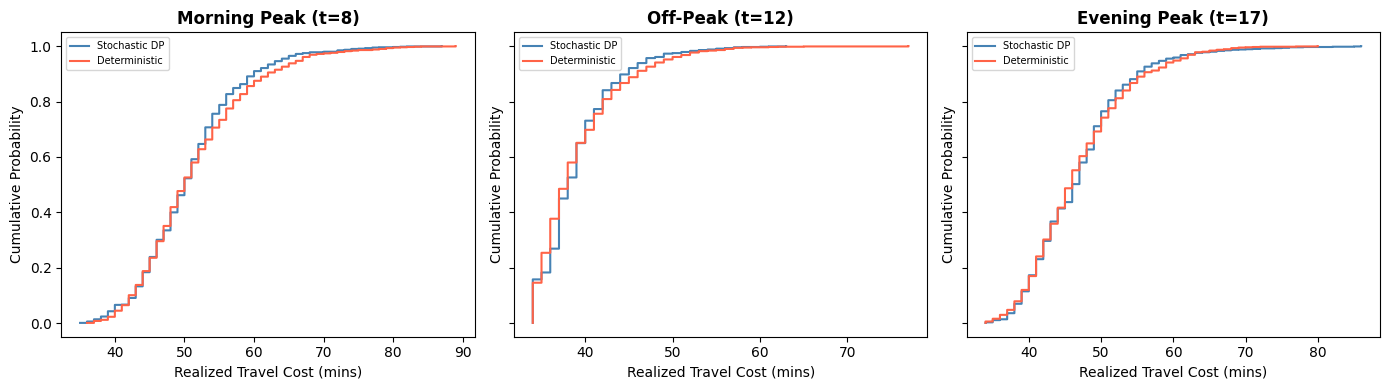

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
labels = ['Morning Peak (t=8)', 'Off-Peak (t=12)', 'Evening Peak (t=17)']
for ax, (t, label) in zip(axes, zip(departure_times, labels)):
    sto_costs = sorted(results_sto[t]['costs'])
    det_costs = sorted(results_det[t]['costs'])
    
    n = len(sto_costs)
    cdf_y = np.arange(1, n + 1) / n

    ax.step(sto_costs, cdf_y, where='post', color='steelblue', label='Stochastic DP')
    ax.step(det_costs, cdf_y, where='post', color='tomato', label='Deterministic')
    
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Realized Travel Cost (mins)')
    ax.set_ylabel('Cumulative Probability')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

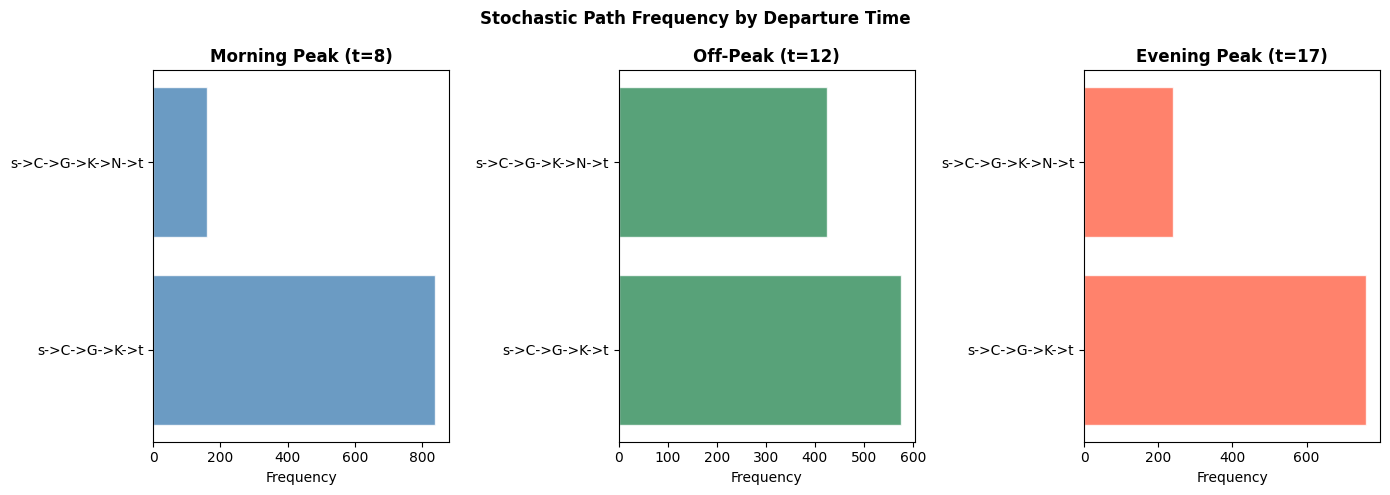

In [18]:
from collections import Counter

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
colors = ['steelblue', 'seagreen', 'tomato']

for ax, (t, color, label) in zip(axes, zip(departure_times, colors, labels)):
    path_counts = Counter(results_sto[t]['paths'])
    paths, counts = zip(*sorted(path_counts.items(), key=lambda x: -x[1]))
    ax.barh(paths, counts, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Frequency')

fig.suptitle('Stochastic Path Frequency by Departure Time', fontweight='bold')
plt.tight_layout()
plt.show()

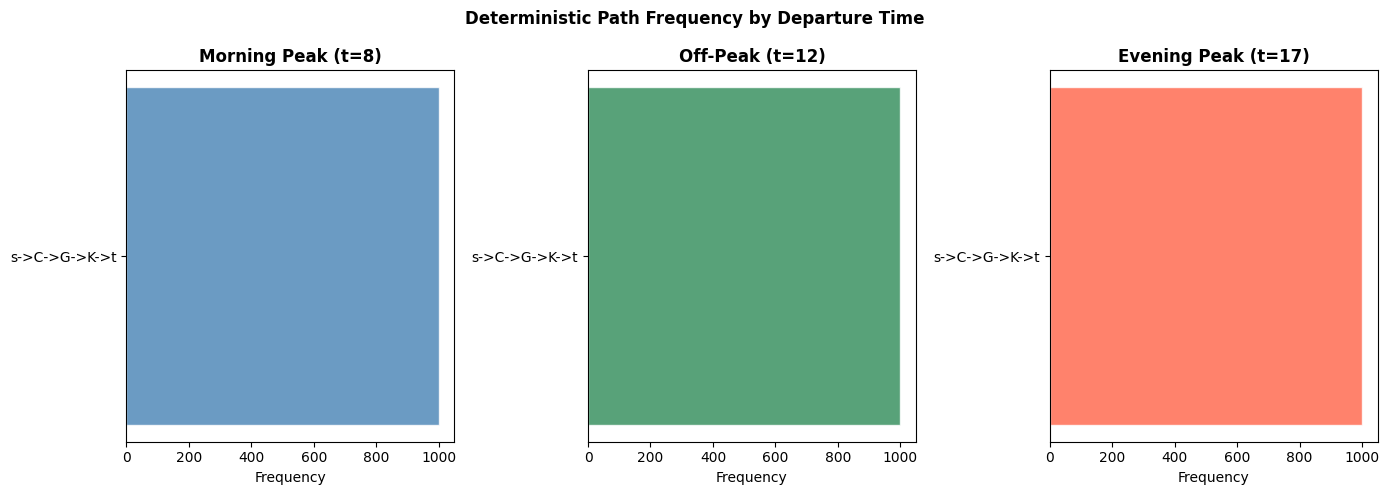

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, (t, color, label) in zip(axes, zip(departure_times, colors, labels)):
    path_counts = Counter(results_det[t]['paths'])
    paths, counts = zip(*sorted(path_counts.items(), key=lambda x: -x[1]))
    ax.barh(paths, counts, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Frequency')

fig.suptitle('Deterministic Path Frequency by Departure Time', fontweight='bold')
plt.tight_layout()
plt.show()

In [20]:
def on_time_rate(costs, departure_time, target_arrival):
    on_time = sum(1 for c in costs if c + departure_time <= target_arrival)
    return on_time / len(costs)

targets = {
    8*60:  8*60 + 45,   # depart 8am, target 8:45am
    12*60: 12*60 + 35,  # depart 12pm, target 12:35pm
    17*60: 17*60 + 40,  # depart 5pm, target 5:40pm
}

In [21]:
on_time_results = {}
for t, target in targets.items():
    on_time_results[t] = {
        'Stochastic DP': on_time_rate(results_sto[t]['costs'], t, target),
        'Deterministic': on_time_rate(results_det[t]['costs'], t, target)
    }
print(f"{'Departure':<25} {'Stochastic DP':>15} {'Deterministic':>15}")
print("-" * 55)
for t, label in zip(departure_times, labels):
    print(f"{label:<25} {on_time_results[t]['Stochastic DP']*100:>14.1f}% {on_time_results[t]['Deterministic']*100:>14.1f}%")

Departure                   Stochastic DP   Deterministic
-------------------------------------------------------
Morning Peak (t=8)                  23.9%           23.6%
Off-Peak (t=12)                     18.3%           25.4%
Evening Peak (t=17)                 17.3%           17.0%


# Departure Time Optimization (use only with no risk aversion)

In [22]:
# Schedule delay parameters
T_star = 9 * 60    # desired arrival time: 9am (540 minutes)
alpha = 0.5        # cost per minute early
beta = 4.0         # cost per minute late (late is worse) # don't make too big or will cause cost explosion

def schedule_delay(arrival_time, T_star=9*60):
    early = max(0, T_star - arrival_time)
    late = max(0, arrival_time - T_star)
    return min(alpha * early + beta * late, 100) # cap at 100 to avoid extreme outliers dominating results

In [23]:
V_sd = {(n, t): float('inf') for n in G.nodes() for t in range(T_min, T_max + 1)}
policy_sd = {}

for t in range(T_min, T_max + 1):
    V_sd[('t', t)] = schedule_delay(t)

for t in range(T_max - 1, T_min - 1, -1):
    for node in reversed(list(nx.topological_sort(G))):
        if node == 't':
            continue
        best_cost = float('inf')
        best_next = None
        for (u, v) in G.edges():
            if u == node:
                cost = new_expected_cost((u, v), t, V_sd, v)
                if cost < best_cost:
                    best_cost = cost
                    best_next = v
        V_sd[(node, t)] = best_cost
        if best_next is not None:
            policy_sd[(node, t)] = best_next

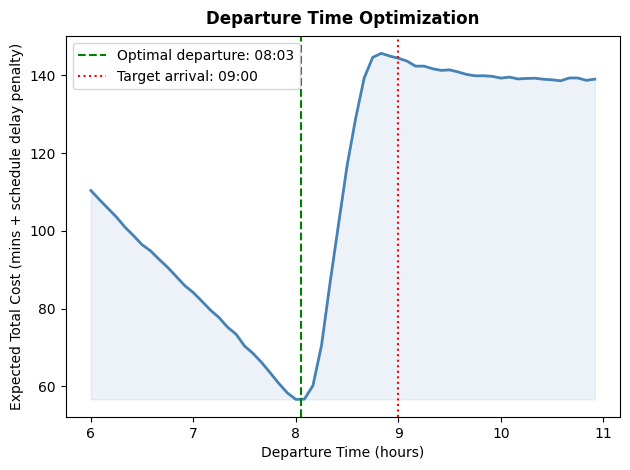

Optimal departure time: 08:03
Expected total cost at optimal departure: 52.19 mins (no risk penalty included)
Expected arrival time: 8:55
Target arrival time: 09:00
Optimal path: s -> A -> E -> H -> M -> N -> t


In [24]:
departure_range = range(6*60, 21*60)  # during non free flow hours

expected_costs = [V_sd[('s', t)] for t in departure_range]
best_t = min(departure_range, key=lambda t: V_sd[('s', t)])
#best_cost = V_sd[('s', best_t)]
mean_cost = np.mean([simulate_trip(policy_sd, 's', best_t)[1] for _ in range(1000)]) # simulate to get mean cost at best_t, which includes stochasticity but not risk penalty

window_start = max(0, T_star - 3*60)
window_end = min(1440, T_star + 2*60)
window_range = range(window_start, window_end, 5)
window_costs = [V_sd[('s', t)] for t in window_range] # this still includes the risk parameter in graph, but gives idea of how cost changes around target arrival time
#window_costs = [np.mean([simulate_trip(policy_sd, 's', t)[1] for _ in range(1000)]) for t in window_range] # simulate to get mean cost at each t in window, which includes stochasticity but not risk penalty

plt.plot([t/60 for t in window_range], window_costs,
          color='steelblue', linewidth=2)
plt.axvline(best_t/60, color='green', linestyle='--', linewidth=1.5,
             label=f'Optimal departure: {best_t//60:02d}:{best_t%60:02d}')
plt.axvline(T_star/60, color='red', linestyle=':', linewidth=1.5,
             label=f'Target arrival: {T_star//60:02d}:{T_star%60:02d}')
plt.fill_between([t/60 for t in window_range], window_costs,
                   min(window_costs), alpha=0.1, color='steelblue')
plt.xlabel('Departure Time (hours)')
plt.ylabel('Expected Total Cost (mins + schedule delay penalty)')
plt.title('Departure Time Optimization', fontweight='bold', y=1.01)
plt.legend()

plt.tight_layout()
plt.show()

# print summary
print(f"Optimal departure time: {best_t//60:02d}:{best_t%60:02d}")
print(f"Expected total cost at optimal departure: {mean_cost:.2f} mins (no risk penalty included)")
print(f"Expected arrival time: {(best_t + mean_cost)//60:.0f}:{(best_t + mean_cost)%60:.0f}")
print(f"Target arrival time: {T_star//60:02d}:{T_star%60:02d}")

# show optimal path
optimal_path = extract_path(policy_sd, 's', best_t)
print(f"Optimal path: {' -> '.join(optimal_path)}")